# Preprocessing - Toyota Corolla

This notebook cleans and prepares the Corolla dataset for merging


## Steps

- 1. Load merged CSV data
- 2. Inspect shape, schema, and missing values
- 3. Standardize column names and text fields
- 4. Convert numeric/date columns to proper types
- 5. Handle missing values with explicit rules
- 6. Remove duplicates and obvious data issues
- 7. Perform outlier checks and apply caps/filters
- 8. Brand filter/Create cleaned output for modeling


## 1. Load Data


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
df_corolla = pd.read_csv("/Users/riteshbhandari/Documents/Dokumentit – Ritesh - MacBook Pro/GitHub/DPPM/datasets/merged/dppm_toyota_corolla_yaris.csv")

## 2. Inspect Data


In [54]:
df_corolla.head()

,product_id,part_name,price,quality_grade,year,oem_number,engine_code,mileage,brand,model,category,subcategory,scrape_date,scrape_timestamp
0,63019913.0,Contact roll Airbag to,238.4,NaN,2019-2027,FI09389104A,2ZRFXE,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,NaN
1,63126049.0,Contact roll Airbag to,226.5,NaN,2019-2027,FI24637030A,NaN,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,NaN
2,61076273.0,Contact roll Airbag to,214.5,NaN,2019-2027,FI27837687A,2ZRFXE,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,NaN
3,63099984.0,Contact roll Airbag to,226.5,NaN,2008-2012,FI22893129A,1ZRFE,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,NaN
4,65759035.0,Contact roll Airbag to,202.6,NaN,2002-2007,FI06018105A,NaN,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,NaN


In [55]:
df_corolla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7435 entries, 0 to 7434
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        5920 non-null   float64
 1   part_name         7435 non-null   object 
 2   price             7433 non-null   float64
 3   quality_grade     7403 non-null   object 
 4   year              7433 non-null   object 
 5   oem_number        6531 non-null   object 
 6   engine_code       4840 non-null   object 
 7   mileage           5265 non-null   float64
 8   brand             7435 non-null   object 
 9   model             7435 non-null   object 
 10  category          7435 non-null   object 
 11  subcategory       7435 non-null   object 
 12  scrape_date       5867 non-null   object 
 13  scrape_timestamp  5303 non-null   object 
dtypes: float64(3), object(11)
memory usage: 813.3+ KB


In [56]:
df_corolla.isna().sum()

product_id          1515
part_name              0
price                  2
quality_grade         32
year                   2
oem_number           904
engine_code         2595
mileage             2170
brand                  0
model                  0
category               0
subcategory            0
scrape_date         1568
scrape_timestamp    2132
dtype: int64

## 3. Drop Unneeded Columns


In [ ]:
# deleting not needed columns 
df_corolla = df_corolla.drop(columns=['engine_code'])  # missing too many values
df_corolla = df_corolla.drop(columns=['scrape_timestamp']) # not needed 
print(df_corolla.shape)


(7435, 12)


## 4. Clean Price


In [58]:
# price column analysis

df_corolla['price'].dtype
df_corolla['price'].head()

0    238.4
1    226.5
2    214.5
3    226.5
4    202.6
Name: price, dtype: float64

In [59]:
# drop missing prices
df_corolla = df_corolla.dropna(subset=['price'])
print(df_corolla.shape)
print(df_corolla["price"].describe())


(7433, 12)
count    7433.000000
mean      251.894793
std       520.143383
min         5.000000
25%        47.400000
50%        94.700000
75%       226.100000
max      3689.000000
Name: price, dtype: float64


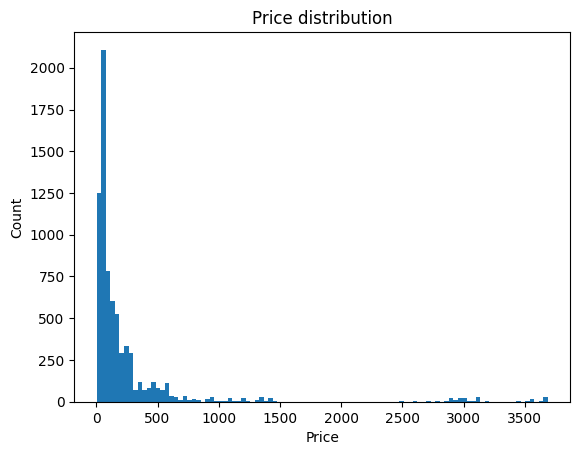

In [179]:
plt.hist(df_corolla["price"], bins=100)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution")
plt.show()

## 5. Clean Year


In [60]:
# Year column analysis
print(df_corolla['year'].dtype)
print(df_corolla['year'].head())
print(df_corolla['year'].describe())
print(df_corolla['year'].unique())

object
0    2019-2027
1    2019-2027
2    2019-2027
3    2008-2012
4    2002-2007
Name: year, dtype: object
count          7433
unique           12
top       2019-2027
freq           2606
Name: year, dtype: object
['2019-2027' '2008-2012' '2002-2007' '2013-2018' '1998-2001' '1993-1997'
 '1983-1987' '1988-1992' '1982-1987' '2020-2027' '2015-2020' '2012-2014']


In [61]:
# splitting year data to end start and width of compatibility
df_corolla[['year_start', 'year_end']] = df_corolla['year'].str.split('-', expand=True)

df_corolla['year_start'] = pd.to_numeric(df_corolla['year_start'], errors='coerce')
df_corolla['year_end'] = pd.to_numeric(df_corolla['year_end'], errors='coerce')

df_corolla['year_span'] = df_corolla['year_end'] - df_corolla['year_start']
df_corolla['year_mid'] = (df_corolla['year_start'] + df_corolla['year_end']) / 2

print(df_corolla[['year','year_start', 'year_end', 'year_span', 'year_mid']].head())

# remove original column 
df_corolla = df_corolla.drop(columns=["year"])


        year  year_start  year_end  year_span  year_mid
0  2019-2027        2019      2027          8    2023.0
1  2019-2027        2019      2027          8    2023.0
2  2019-2027        2019      2027          8    2023.0
3  2008-2012        2008      2012          4    2010.0
4  2002-2007        2002      2007          5    2004.5


## 6. Convert Dates

In [180]:
# Converting datetime 
df_corolla["scrape_date"] = pd.to_datetime(df_corolla["scrape_date"], errors="coerce")
df_corolla["scrape_date"].dtype

dtype('<M8[ns]')

## 7. Final Checks

In [182]:
# Final checks before merging
print(f" Mileage: {df_corolla['mileage'].dtype}")
print(f" Quality Grade: {df_corolla['quality_grade'].dtype}")
print(f" Missing Values: {df_corolla.isna().sum()}")

 Mileage: float64
 Quality Grade: object
 Missing Values: product_id       1515
part_name           0
price               0
quality_grade      30
oem_number        902
mileage          2168
brand               0
model               0
category            0
subcategory         0
scrape_date      1559
year_start          0
year_end            0
year_span           0
year_mid            0
dtype: int64


In [183]:
# convert product id to integer
df_corolla["product_id"] = df_corolla["product_id"].astype("Int64")
df_corolla.dtypes

product_id                Int64
part_name                object
price                   float64
quality_grade            object
oem_number               object
mileage                 float64
brand                    object
model                    object
category                 object
subcategory              object
scrape_date      datetime64[ns]
year_start                int64
year_end                  int64
year_span                 int64
year_mid                float64
dtype: object

## 8. Brand Filter


In [ ]:
# filter out other car brands (yaris)
df_corolla = df_corolla[df_corolla["model"] == "Corolla"]
df_corolla.head()

,product_id,part_name,price,quality_grade,oem_number,mileage,brand,model,category,subcategory,scrape_date,year_start,year_end,year_span,year_mid
0,63019913.0,Contact roll Airbag to,238.4,NaN,FI09389104A,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,2019,2027,8,2023.0
1,63126049.0,Contact roll Airbag to,226.5,NaN,FI24637030A,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,2019,2027,8,2023.0
2,61076273.0,Contact roll Airbag to,214.5,NaN,FI27837687A,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,2019,2027,8,2023.0
3,63099984.0,Contact roll Airbag to,226.5,NaN,FI22893129A,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,2008,2012,4,2010.0
4,65759035.0,Contact roll Airbag to,202.6,NaN,FI06018105A,NaN,Toyota,Corolla,Airbag,Contact roll Airbag,2026-02-01,2002,2007,5,2004.5


# 9. Save Output


In [ ]:
# save the cleaned csv
df_corolla.to_csv("skoda_cleaned.csv", index=False)